# VGG16 CIFAR10 Training: FP16 Base + FP8 Low Precision

## Mixed-Precision Training dengan GradScaler untuk Underflow Protection

Notebook ini mendemonstrasikan training VGG16 pada CIFAR-10 menggunakan **dual-level mixed precision**:

| Level | Precision | Mekanisme | Diterapkan Pada |
|-------|-----------|-----------|------------------|
| **Base** | FP16 | `torch.cuda.amp.autocast` + `GradScaler` | Semua layer default |
| **Low** | FP8 (E4M3/E5M2) | Native FP8 casting + delayed scaling | Conv2d & Linear terpilih |

### Mengapa GradScaler Diperlukan?

FP16 memiliki dynamic range yang terbatas (~5.96e-8 hingga 65504). Saat training dengan FP16:
- **Underflow**: Gradient kecil bisa menjadi nol (loss of information)
- **Overflow**: Gradient besar bisa menjadi `inf`

`GradScaler` mengatasi ini dengan:
1. **Scaling loss** sebelum backward pass (mencegah underflow)
2. **Unscaling gradients** sebelum optimizer step
3. **Skipping steps** jika ditemukan `inf`/`nan` gradients
4. **Dynamic scale adjustment** — naik jika stabil, turun jika overflow

### FP8 Layer Selection Strategy

- **E4M3** (4-bit exponent, 3-bit mantissa): Digunakan untuk forward pass — range ±448
- **E5M2** (5-bit exponent, 2-bit mantissa): Digunakan untuk backward pass — range ±57344

Layer-layer awal (conv) dan layer pertama FC dipilih untuk FP8 karena
memiliki toleransi lebih tinggi terhadap quantization noise.

In [1]:
# ============================================================
# Cell 2: Imports & Environment Check
# ============================================================

import os, sys
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.cuda.amp import GradScaler, autocast

# ---- Add project root to sys.path ----
PROJECT_ROOT = os.path.abspath('.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
print(f'[INFO] Project root: {PROJECT_ROOT}')

# ---- Import ext3 modules ----
from ext3.nn import flatten
from ext3.nn.nn_native import (
    NativeConv2d, NativeLinear, NativeBatchNorm2d,
    NativeReLU, NativeMaxPool2d, NativeAdaptiveAvgPool2d,
    NativeDropout, reset_fp8_manager
)
from ext3.core.include.native_precision import (
    NativePrecisionMode, check_fp8_support, FP8Config
)
from ext3.core.emodlobj import EModlObjMgr
from ext3.core.include.dtype import Dtype, FP16
from ext3.core.include.pasn import Pasn
from ext3.core.include.ttype import Ttype
from ext3.util.apa_manager import (
    assign_precision, APAStabilityMonitor, StabilityEvent
)

# Environment Check
print(f"\n=== Environment Check ===")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name       : {torch.cuda.get_device_name(0)}")
print(f"FP8 Supported  : {check_fp8_support()}")


[INFO] Project root: c:\Users\PC\Documents\penelitian_miftah\github_remote\Adaptive-Precision-Assigment

=== Environment Check ===
PyTorch Version: 2.12.1+cu132
CUDA Available : True
GPU Name       : NVIDIA GeForce RTX 5060 Ti
FP8 Supported  : True


In [2]:
# ============================================================
# Cell 3: Global Configuration
# ============================================================

# NOTE: TF32 NOT enabled here — we use FP16 as base
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

CONFIG = {
    'batch_size': 128,
    'epochs': 50,
    'lr': 0.01,
    'momentum': 0.9,
    'weight_decay': 5e-4,
    'num_workers': 0,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    
    # --- Native APA (Adaptive Precision Assignment) Config ---
    'pa_upd_schm': 'topr_dec',
    'pa_upd_rmin': 0.3,
    'pa_upd_rmax': 0.4,
    
    # GradScaler config
    'grad_scaler_init_scale': 2.**16,
    'grad_scaler_growth_interval': 2000,
}

print("\n=== Training Configuration ===")
for k, v in CONFIG.items():
    print(f"  {k:20s}: {v}")



=== Training Configuration ===
  batch_size          : 128
  epochs              : 50
  lr                  : 0.01
  momentum            : 0.9
  weight_decay        : 0.0005
  num_workers         : 0
  device              : cuda
  pa_upd_schm         : topr_dec
  pa_upd_rmin         : 0.3
  pa_upd_rmax         : 0.4
  grad_scaler_init_scale: 65536.0
  grad_scaler_growth_interval: 2000


In [3]:
# ============================================================
# Cell 4: VGG16 Model Definition
# ============================================================
# Arsitektur VGG16 dengan Native Precision layers dari ext3
# Menggunakan NativeConv2d, NativeLinear, dll. agar tiap layer
# bisa di-assign precision mode secara independen.

class VGG16Native(nn.Module):
    """
    VGG16 menggunakan Native Precision layers.
    
    Arsitektur:
    - 13 Conv2d layers (NativeConv2d) dalam 5 blok
    - 3 Linear layers (NativeLinear) sebagai classifier
    - BatchNorm2d setelah setiap Conv2d (modern VGG variant)
    - Disesuaikan untuk CIFAR-10 (input 32x32, 10 classes)
    """
    
    def __init__(self, num_classes=10):
        super(VGG16Native, self).__init__()
        
        # ---- Feature Extractor (Convolutional Blocks) ----
        self.features = nn.Sequential(
            # Block 1: 3 -> 64, 2 conv layers
            NativeConv2d(3, 64, kernel_size=3, padding=1),       # conv_layers[0]
            NativeBatchNorm2d(64),
            NativeReLU(inplace=False),
            NativeConv2d(64, 64, kernel_size=3, padding=1),      # conv_layers[1]
            NativeBatchNorm2d(64),
            NativeReLU(inplace=False),
            NativeMaxPool2d(kernel_size=2, stride=2),
            
            # Block 2: 64 -> 128, 2 conv layers
            NativeConv2d(64, 128, kernel_size=3, padding=1),     # conv_layers[2]
            NativeBatchNorm2d(128),
            NativeReLU(inplace=False),
            NativeConv2d(128, 128, kernel_size=3, padding=1),    # conv_layers[3]
            NativeBatchNorm2d(128),
            NativeReLU(inplace=False),
            NativeMaxPool2d(kernel_size=2, stride=2),
            
            # Block 3: 128 -> 256, 3 conv layers
            NativeConv2d(128, 256, kernel_size=3, padding=1),    # conv_layers[4]
            NativeBatchNorm2d(256),
            NativeReLU(inplace=False),
            NativeConv2d(256, 256, kernel_size=3, padding=1),    # conv_layers[5]
            NativeBatchNorm2d(256),
            NativeReLU(inplace=False),
            NativeConv2d(256, 256, kernel_size=3, padding=1),    # conv_layers[6]
            NativeBatchNorm2d(256),
            NativeReLU(inplace=False),
            NativeMaxPool2d(kernel_size=2, stride=2),
            
            # Block 4: 256 -> 512, 3 conv layers
            NativeConv2d(256, 512, kernel_size=3, padding=1),    # conv_layers[7]
            NativeBatchNorm2d(512),
            NativeReLU(inplace=False),
            NativeConv2d(512, 512, kernel_size=3, padding=1),    # conv_layers[8]
            NativeBatchNorm2d(512),
            NativeReLU(inplace=False),
            NativeConv2d(512, 512, kernel_size=3, padding=1),    # conv_layers[9]
            NativeBatchNorm2d(512),
            NativeReLU(inplace=False),
            NativeMaxPool2d(kernel_size=2, stride=2),
            
            # Block 5: 512 -> 512, 3 conv layers
            NativeConv2d(512, 512, kernel_size=3, padding=1),    # conv_layers[10]
            NativeBatchNorm2d(512),
            NativeReLU(inplace=False),
            NativeConv2d(512, 512, kernel_size=3, padding=1),    # conv_layers[11]
            NativeBatchNorm2d(512),
            NativeReLU(inplace=False),
            NativeConv2d(512, 512, kernel_size=3, padding=1),    # conv_layers[12]
            NativeBatchNorm2d(512),
            NativeReLU(inplace=False),
            NativeMaxPool2d(kernel_size=2, stride=2),
        )
        
        # ---- Adaptive Pooling ----
        self.avgpool = NativeAdaptiveAvgPool2d((1, 1))
        
        # ---- Classifier (Fully Connected Layers) ----
        self.classifier = nn.Sequential(
            NativeLinear(512, 512),                               # linear_layers[0]
            NativeReLU(inplace=False),
            NativeDropout(0.5),
            NativeLinear(512, 512),                               # linear_layers[1]
            NativeReLU(inplace=False),
            NativeDropout(0.5),
            NativeLinear(512, num_classes),                       # linear_layers[2]
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = flatten(x, 1)
        x = self.classifier(x)
        return x


# Quick test
print('[INFO] VGG16Native architecture created.')
_test_model = VGG16Native(num_classes=10)
_n_params = sum(p.numel() for p in _test_model.parameters())
print(f'[INFO] Total parameters: {_n_params:,}')

# Count layer types
_n_conv = sum(1 for m in _test_model.modules() if isinstance(m, NativeConv2d))
_n_linear = sum(1 for m in _test_model.modules() if isinstance(m, NativeLinear))
print(f'[INFO] NativeConv2d layers  : {_n_conv}')
print(f'[INFO] NativeLinear layers  : {_n_linear}')


[INFO] VGG16Native architecture created.
[INFO] Total parameters: 15,253,578
[INFO] NativeConv2d layers  : 13
[INFO] NativeLinear layers  : 3


In [4]:
# ============================================================
# Cell 5: Precision Assignment Setup
# ============================================================

# APA v2.0 — imported via ext3.nn imports cell above
print("APA v2.0: assign_precision + APAStabilityMonitor imported ✓")


assign_precision() defined ✓


In [5]:
# ============================================================
# Cell 6: CIFAR-10 Data Pipeline
# ============================================================
# Standard data augmentation untuk CIFAR-10:
# - RandomCrop 32x32 dengan padding 4
# - RandomHorizontalFlip
# - Normalize dengan mean/std CIFAR-10

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010),
    ),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010),
    ),
])

# Download dan load dataset
trainset = torchvision.datasets.CIFAR10(
    root='./dataset/cifar10', train=True, download=True, transform=transform_train
)
testset = torchvision.datasets.CIFAR10(
    root='./dataset/cifar10', train=False, download=True, transform=transform_test
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=CONFIG['batch_size'],
    shuffle=True, num_workers=CONFIG['num_workers'],
    pin_memory=True,
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=CONFIG['batch_size'],
    shuffle=False, num_workers=CONFIG['num_workers'],
    pin_memory=True,
)

print(f'[DATA] Training samples  : {len(trainset):,}')
print(f'[DATA] Test samples      : {len(testset):,}')
print(f'[DATA] Training batches  : {len(trainloader)}')
print(f'[DATA] Test batches      : {len(testloader)}')
print(f'[DATA] Batch size        : {CONFIG["batch_size"]}')
print(f'[DATA] Classes           : {trainset.classes}')

[DATA] Training samples  : 50,000
[DATA] Test samples      : 10,000
[DATA] Training batches  : 391
[DATA] Test batches      : 79
[DATA] Batch size        : 128
[DATA] Classes           : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
# ============================================================
# Cell 7: VRAM Monitoring + Loss Stability Checker
# ============================================================

def get_vram_mb():
    """Return current GPU VRAM usage in MB."""
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / (1024**2)
    return 0.0


class LossStabilityChecker:
    """
    Detects NaN/Inf losses and triggers FP8 -> FP16 fallback.
    
    Ketika FP8 quantization terlalu agresif, loss bisa menjadi NaN/Inf.
    Checker ini menghitung berapa kali berturut-turut loss abnormal.
    Jika melebihi `patience`, trigger fallback ke FP16.
    
    Attributes:
        nan_count: Consecutive NaN/Inf count
        patience: Maximum consecutive NaN/Inf sebelum fallback
        triggered: True jika fallback sudah di-trigger
    """
    
    def __init__(self, patience=3):
        self.nan_count = 0
        self.patience = patience
        self.triggered = False
    
    def check(self, loss_val):
        """
        Check apakah loss value abnormal.
        
        Args:
            loss_val: Float loss value dari training
            
        Returns:
            bool: True jika harus disable FP8 (fallback triggered)
        """
        if math.isnan(loss_val) or math.isinf(loss_val):
            self.nan_count += 1
            print(f'  [STABILITY] NaN/Inf detected! Count: {self.nan_count}/{self.patience}')
            if self.nan_count >= self.patience:
                self.triggered = True
                return True  # Signal to disable FP8
        else:
            self.nan_count = 0  # Reset counter on normal loss
        return False


print('[INFO] VRAM monitor and LossStabilityChecker ready.')
print(f'[INFO] Current VRAM usage: {get_vram_mb():.1f} MB')

[INFO] VRAM monitor and LossStabilityChecker ready.
[INFO] Current VRAM usage: 0.0 MB


In [7]:
# ============================================================
# Cell 8: Training Function (APA v2.0 — GradScaler + EMA-Gated Monitor)
# ============================================================

def train_epoch(model, loader, criterion, optimizer, scaler, device, monitor):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    total_grad_overflows = 0
    epoch_events = {"stable": 0, "nan": 0, "spike": 0, "overflow": 0}
    
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        
        with autocast(dtype=torch.float16):
            outputs = model(inputs)
            loss = criterion(outputs, targets)
        
        scaler.scale(loss).backward()
        
        scaler.step(optimizer)
        scale_before = scaler.get_scale()
        scaler.update()
        scale_after = scaler.get_scale()
        if scale_after < scale_before:
            total_grad_overflows += 1
        
        # --- APA v2.0: EMA-Gated Stability Monitor ---
        # Reuse loss.item() for both logging AND monitoring (zero extra sync)
        loss_val = loss.item()
        event = monitor.step(loss_val, model, FP16)
        
        if event == StabilityEvent.LOSS_NAN:
            epoch_events["nan"] += 1
        elif event == StabilityEvent.LOSS_SPIKE:
            epoch_events["spike"] += 1
        elif event == StabilityEvent.GRADIENT_OVERFLOW:
            epoch_events["overflow"] += 1
        
        total_loss += loss_val * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
    flags = EModlObjMgr.get_inc_ts_prec_flag()
    total_promotions = sum([1 for f in flags if f > 0.0])
    
    avg_loss = total_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy, total_promotions, total_grad_overflows, epoch_events

print("train_epoch() defined ✓ [APA v2.0: GradScaler + EMA-Gated]")


train_epoch() defined ✓


In [8]:
# ============================================================
# Cell 9: Evaluation Function
# ============================================================
# Evaluasi juga menggunakan autocast FP16 agar konsisten
# dengan kondisi training (precision yang sama).

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Evaluate model pada test set dengan autocast FP16.
    
    Args:
        model: VGG16Native model (eval mode)
        loader: Test DataLoader
        criterion: Loss function
        device: CUDA device
    
    Returns:
        tuple: (avg_loss, accuracy%)
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Eval juga dengan autocast FP16
        with torch.cuda.amp.autocast(dtype=torch.float16):
            outputs = model(inputs)
            loss = criterion(outputs, targets)
        
        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    avg_loss = total_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy


print('[INFO] evaluate() function defined.')

[INFO] evaluate() function defined.


In [9]:
# ============================================================
# Cell 10: FP8 Fallback Function
# ============================================================
# Emergency fallback: jika training tidak stabil (NaN/Inf berulang),
# semua FP8 layers di-switch ke FP16 untuk menyelamatkan training.

def disable_fp8_layers(model):
    """
    Emergency fallback: switch all FP8 layers to FP16.
    
    Dipanggil ketika LossStabilityChecker mendeteksi terlalu banyak
    NaN/Inf losses berturut-turut. Ini menunjukkan bahwa FP8 quantization
    terlalu agresif untuk model/data ini.
    
    Setelah fallback, training berlanjut sepenuhnya dalam FP16.
    
    Args:
        model: VGG16Native model instance
    """
    fallback_count = 0
    for module in model.modules():
        if hasattr(module, '_native_mode') and module._native_mode == NativePrecisionMode.LOW_FP8:
            module.set_native_precision('base_fp16')
            fallback_count += 1
    
    print(f'\n{"=" * 60}')
    print(f'[WARNING] FP8 layers disabled — falling back to FP16')
    print(f'[WARNING] due to training instability (NaN/Inf detected).')
    print(f'[WARNING] {fallback_count} layers switched from FP8 -> FP16.')
    print(f'{"=" * 60}\n')


print('[INFO] disable_fp8_layers() fallback function defined.')

[INFO] disable_fp8_layers() fallback function defined.


In [10]:
# ============================================================
# Cell 11: Main Training Loop (APA v2.0)
# ============================================================

model = VGG16Native(num_classes=10).to(CONFIG['device'])

reset_fp8_manager()
pasn_manager = assign_precision(model, CONFIG)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=CONFIG['lr'], 
                      momentum=CONFIG['momentum'], weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])

scaler = GradScaler(
    init_scale=CONFIG['grad_scaler_init_scale'],
    growth_interval=CONFIG['grad_scaler_growth_interval']
)

# --- APA v2.0: Initialize EMA-Gated Stability Monitor ---
monitor = APAStabilityMonitor(
    ema_alpha=0.1,            # EMA smoothing (tunable: 0.05-0.3)
    variance_threshold=2.0,   # Spike sensitivity in σ (tunable: 1.5-4.0)
    ovr_thrs=0.0,             # Any overflow triggers promotion
    warmup_steps=10,          # EMA calibration period
)
print(f"APA v2.0 Monitor initialized: α={0.1}, σ_thresh={2.0}, warmup={10}")

history = {
    'train_loss': [],
    'train_acc': [],
    'test_acc': [],
    'vram': [],
    'lr': [],
    'promotions': [],
    'grad_overflows': [],
    'spike_events': [],
}

print("\n" + "=" * 120)
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Acc':>8} | {'Promoted':>8} | {'Grad Ovr':>8} | {'Spikes':>6} | {'GPU Syncs':>9} | {'VRAM MB':>8} | {'Time':>6} | {'LR':>8}")
print("-" * 120)

best_acc = 0.0
cumulative_promotions = 0

for epoch in range(1, CONFIG['epochs'] + 1):
    start_time = time.time()
    current_lr = optimizer.param_groups[0]['lr']
    
    train_loss, train_acc, promotions, grad_overflows, events = train_epoch(
        model, trainloader, criterion, optimizer, scaler, CONFIG['device'], monitor
    )
    _, test_acc = evaluate(model, testloader, criterion, CONFIG['device'])
    scheduler.step()
    
    epoch_time = time.time() - start_time
    vram = get_vram_mb()
    cumulative_promotions += promotions
    stats = monitor.get_stats()
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    history['vram'].append(vram)
    history['lr'].append(current_lr)
    history['promotions'].append(cumulative_promotions)
    history['grad_overflows'].append(grad_overflows)
    history['spike_events'].append(stats['spike_events'])
    
    best_marker = " *" if test_acc > best_acc else ""
    best_acc = max(best_acc, test_acc)
    
    print(f"{epoch:5d} | {train_loss:10.4f} | {train_acc:8.2f}% | {test_acc:7.2f}% | {promotions:5d} ↑ | {grad_overflows:8d} | {stats['spike_events']:6d} | {stats['tier2_checks']:9d} | {vram:7.1f}M | {epoch_time:5.1f}s | {current_lr:.6f}{best_marker}")

print("=" * 120)
print(f"Training Complete! Best Test Accuracy: {best_acc:.2f}%")
print(f"Total layers promoted to FP16: {cumulative_promotions}")
print(f"APA v2.0 Efficiency: {stats['sync_efficiency']}")



PRECISION ASSIGNMENT (Original APA Architecture - FP16 Base)


C:\Users\PC\AppData\Local\Temp\ipykernel_4060\4144933924.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.float16):


  Target Demotion Ratio : 0.300
  Total Layers          : 52
  Demoted Layers        : 1

=== Grouping & Demotion Map ===
Group   0 | NativeConv2d                   | Y=base_fp16  P=base_fp16 
Group   0 | NativeBatchNorm2d              | Y=base_fp16  P=base_fp16 
Group   0 | NativeReLU                     | Y=base_fp16  P=base_fp16 
Group   1 | NativeConv2d                   | Y=low_fp8    P=base_fp16  [DEMOTED: Y=FP8]
Group   1 | NativeBatchNorm2d              | Y=low_fp8    P=low_fp8    [DEMOTED: Y=FP8, P=FP8]
Group   1 | NativeReLU                     | Y=low_fp8    P=base_fp16  [DEMOTED: Y=FP8]
Group   1 | NativeMaxPool2d                | Y=low_fp8    P=base_fp16  [DEMOTED: Y=FP8]
Group   1 | NativeConv2d                   | Y=low_fp8    P=low_fp8    [DEMOTED: Y=FP8, P=FP8]
Group   1 | NativeBatchNorm2d              | Y=low_fp8    P=low_fp8    [DEMOTED: Y=FP8, P=FP8]
Group   1 | NativeReLU                     | Y=low_fp8    P=base_fp16  [DEMOTED: Y=FP8]
Group   2 | NativeConv2d    

C:\Users\PC\AppData\Local\Temp\ipykernel_4060\439371515.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(
C:\Users\PC\AppData\Local\Temp\ipykernel_4060\1486213811.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.float16):
c:\Users\PC\Documents\penelitian_miftah\github_remote\Adaptive-Precision-Assigment\ext3\nn\nn_native.py:159: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.float16):
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
C:

    1 |     1.6081 |    38.98% |   47.63% |    15 ↑ |        0 |   242.3M |  37.4s | 0.010000 *
    2 |     1.0750 |    62.31% |   57.47% |     0 ↑ |        0 |   242.3M |  38.7s | 0.009990 *
    3 |     0.8645 |    70.67% |   67.53% |     0 ↑ |        0 |   242.3M |  37.9s | 0.009961 *
    4 |     0.7182 |    75.87% |   77.22% |     0 ↑ |        0 |   242.3M |  38.5s | 0.009911 *
    5 |     0.6341 |    79.25% |   79.35% |     0 ↑ |        0 |   242.3M |  38.8s | 0.009843 *
    6 |     0.5756 |    81.05% |   79.30% |     0 ↑ |        1 |   242.3M |  37.9s | 0.009755
    7 |     0.5250 |    82.74% |   81.67% |     0 ↑ |        0 |   242.3M |  38.8s | 0.009649 *
    8 |     0.4791 |    84.30% |   81.58% |     0 ↑ |        0 |   242.3M |  38.3s | 0.009524
    9 |     0.4451 |    85.41% |   84.18% |     0 ↑ |        0 |   242.3M |  38.3s | 0.009382 *
   10 |     0.4160 |    86.36% |   85.75% |     0 ↑ |        0 |   242.3M |  38.7s | 0.009222 *
   11 |     0.3907 |    87.17% |   86.26% | 

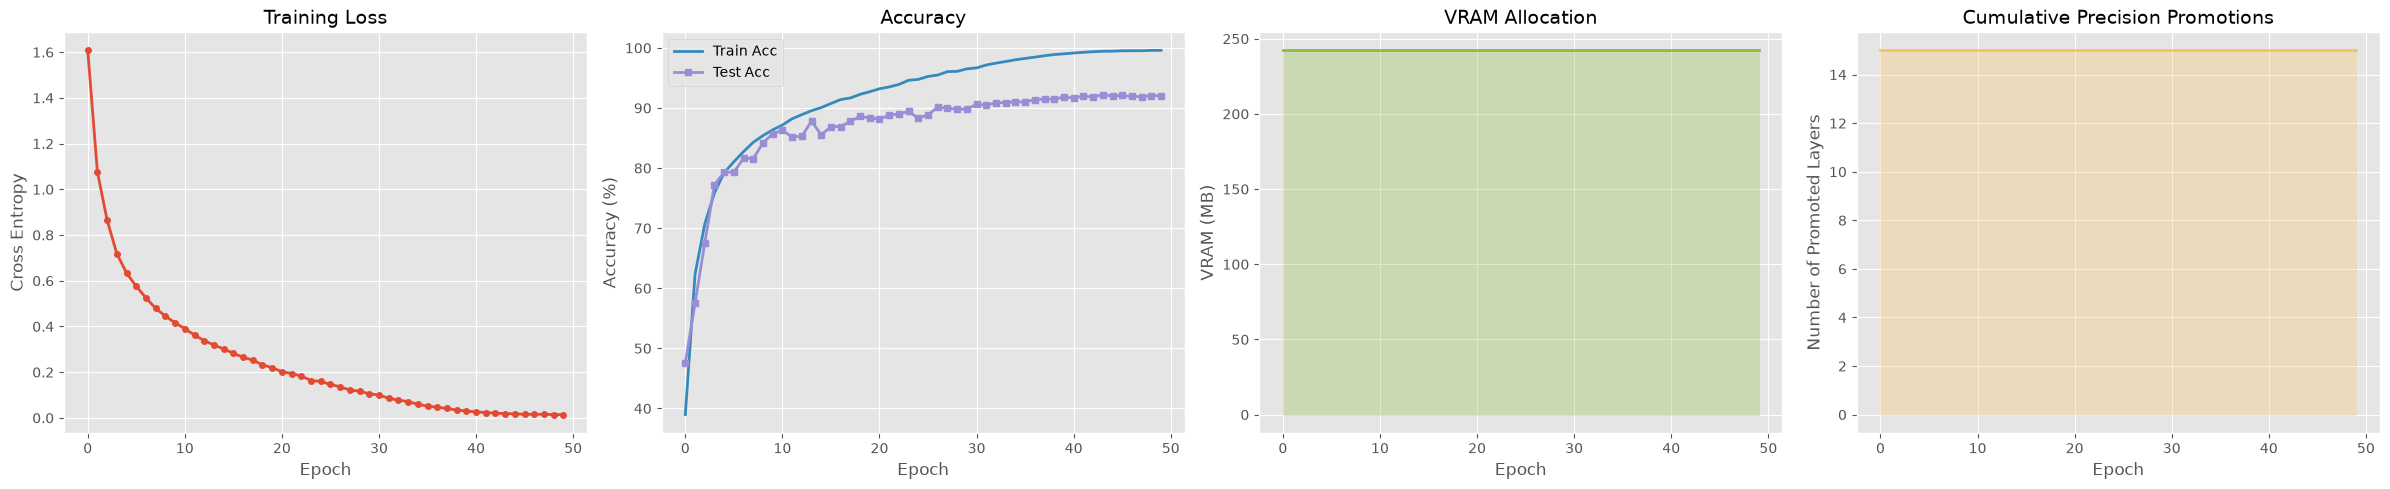

In [11]:
# ============================================================
# Cell 12: Visualization
# ============================================================

plt.style.use('ggplot')
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(24, 5))

# 1. Loss Curve
ax1.plot(history['train_loss'], color='#E24A33', linewidth=2, marker='o', markersize=4)
ax1.set_title('Training Loss', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Cross Entropy', fontsize=12)

# 2. Accuracy Curve
ax2.plot(history['train_acc'], label='Train Acc', color='#348ABD', linewidth=2)
ax2.plot(history['test_acc'], label='Test Acc', color='#988ED5', linewidth=2, marker='s', markersize=4)
ax2.set_title('Accuracy', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.legend()

# 3. VRAM Usage
ax3.plot(history['vram'], color='#8EBA42', linewidth=2, fillstyle='bottom')
ax3.fill_between(range(len(history['vram'])), history['vram'], alpha=0.3, color='#8EBA42')
ax3.set_title('VRAM Allocation', fontsize=14)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('VRAM (MB)', fontsize=12)

# 4. Cumulative Promotions
ax4.plot(history['promotions'], color='#FBC15E', linewidth=2, drawstyle='steps-post')
ax4.fill_between(range(len(history['promotions'])), history['promotions'], alpha=0.3, color='#FBC15E', step='post')
ax4.set_title('Cumulative Precision Promotions', fontsize=14)
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('Number of Promoted Layers', fontsize=12)

plt.tight_layout()
plt.savefig('vgg16_fp16_fp8_training_results.png', dpi=150, bbox_inches='tight')
plt.show()


## Analisis: FP8 Scaling Mechanism & GradScaler Interaction

### 1. Mekanisme FP8 Delayed Scaling

FP8 menggunakan **delayed scaling** untuk menentukan scale factor yang optimal:

```
Iterasi t:
  1. Ambil scale factor dari history (dihitung di iterasi t-1)
  2. Cast input/weight ke FP8: tensor_fp8 = (tensor * scale).clamp(-max_val, max_val).to(fp8)
  3. Execute forward pass
  4. Record amax (max absolute value) dari tensor asli
  5. Update scale: scale = dtype_max / max(amax_history)
```

Scale factor "delayed by 1 step" karena dihitung berdasarkan statistics dari iterasi sebelumnya.
Ini lebih stabil daripada per-tensor scaling yang langsung menggunakan amax dari batch saat ini.

### 2. Interaksi GradScaler dengan FP8

Dalam notebook ini, ada **dua level scaling** yang bekerja bersamaan:

| Level | Mekanisme | Tujuan |
|-------|-----------|--------|
| **GradScaler** (training loop) | Dynamic loss scaling | Mencegah gradient underflow di FP16 |
| **FP8ScalingManager** (per-layer) | Delayed per-tensor scaling | Memetakan tensor ke FP8 range |

Keduanya bekerja **independen** dan **komplementer**:
- GradScaler mengurus **backward pass** (gradient magnitudes)
- FP8ScalingManager mengurus **forward pass** (activation & weight magnitudes)

### 3. Pencegahan Underflow & Overflow

#### FP16 Underflow Prevention (via GradScaler):
- **Problem**: FP16 min subnormal = 5.96e-8. Gradien kecil bisa menjadi 0.
- **Solution**: Scale loss sebelum backward → gradien diperbesar → tidak underflow.
- **Dynamic adjustment**: Jika ada overflow (inf grads), scale diturunkan 2x. Jika stabil selama `growth_interval` steps, scale dinaikkan 2x.

#### FP8 Range Management (via FP8ScalingManager):
- **Problem**: FP8 E4M3 max = 448, E5M2 max = 57344. Range sangat terbatas.
- **Solution**: Per-tensor scale factor memetakan dynamic range tensor ke FP8 representable range.
- **Delayed scaling**: Menggunakan history `amax` dari 16 iterasi terakhir untuk stabilitas.

### 4. Mengapa E4M3 untuk Forward dan E5M2 untuk Backward?

| Format | Exponent | Mantissa | Range | Precision | Digunakan Untuk |
|--------|----------|----------|-------|-----------|------------------|
| **E4M3** | 4 bit | 3 bit | ±448 | Lebih tinggi | Forward (weight & activation) |
| **E5M2** | 5 bit | 2 bit | ±57344 | Lebih rendah | Backward (gradients) |

**Alasan pemilihan:**

1. **Forward pass (E4M3)**:
   - Weights dan activations biasanya memiliki distribusi yang **compact** (range kecil)
   - Precision lebih penting daripada range → E4M3 (3-bit mantissa) memberikan resolusi lebih baik
   - Dengan delayed scaling, range ±448 sudah cukup

2. **Backward pass (E5M2)**:
   - Gradients memiliki distribusi **wide** dan bisa sangat kecil atau sangat besar
   - Dynamic range lebih penting → E5M2 (5-bit exponent) memberikan range ±57344
   - Precision lebih rendah bisa ditoleransi karena gradients di-aggregate (averaged)

### 5. Overflow Detection & Fallback

Notebook ini memiliki mekanisme **safety net** berlapis:

1. **GradScaler overflow detection**: Skip optimizer step jika ada inf gradients
2. **Gradient clipping** (max_norm=1.0): Mencegah gradient explosion
3. **LossStabilityChecker**: Monitor NaN/Inf loss, trigger FP8→FP16 fallback jika berulang
4. **FP8 hardware fallback**: Jika GPU tidak support FP8, otomatis fallback ke FP16

Mekanisme berlapis ini memastikan training tetap konvergen meskipun menggunakan precision sangat rendah.